RGB Image Dimensions: (335, 500, 3)
GC Image Dimensions: (429, 640)


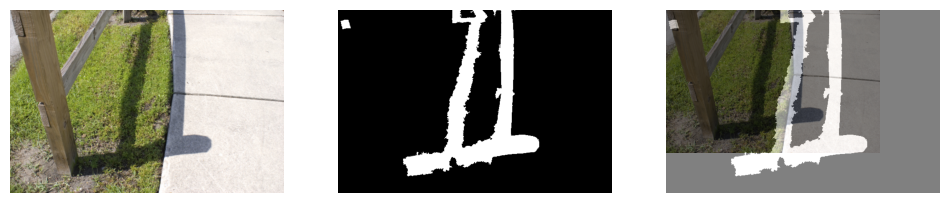

In [90]:
import cv2
import matplotlib.pyplot as plt

img_rgb = cv2.cvtColor(cv2.imread('data/shadow_remove/images.jpg'), cv2.COLOR_BGR2RGB)
img_gc = cv2.imread('data/shadow_remove/binary.png', cv2.IMREAD_GRAYSCALE)

print("RGB Image Dimensions:", img_rgb.shape)
print("GC Image Dimensions:", img_gc.shape)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_gc, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_rgb)
plt.imshow(img_gc, cmap='gray', alpha=0.5)
plt.axis('off')

plt.show()

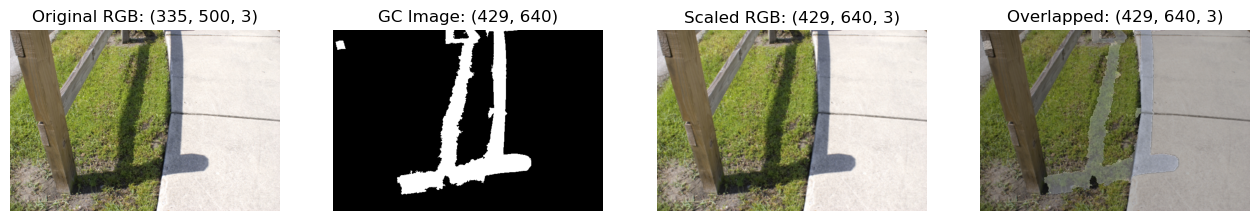

In [91]:
import numpy as np

h_rgb, w_rgb, _ = img_rgb.shape
h_gc, w_gc = img_gc.shape

scale_factor_h = h_gc / h_rgb
scale_factor_w = w_gc / w_rgb

img_rgb_scaled = cv2.resize(img_rgb, (w_gc, h_gc), interpolation=cv2.INTER_LINEAR)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title(f"Original RGB: {img_rgb.shape}")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_gc, cmap='gray')
plt.title(f"GC Image: {img_gc.shape}")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_rgb_scaled)
plt.title(f"Scaled RGB: {img_rgb_scaled.shape}")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_rgb_scaled)
plt.title(f"Overlapped: {img_rgb_scaled.shape}")
plt.imshow(img_gc, cmap='gray', alpha=0.3)
plt.axis('off')

plt.show()

In [92]:
alpha_matrix = np.loadtxt('data/shadow_remove/alpha.txt')
# alpha_matrix = 1 - alpha_matrix
print("Matrix Shape:", alpha_matrix.shape)
print("Unique Values:", np.unique(alpha_matrix))

Matrix Shape: (429, 640)
Unique Values: [0. 1.]


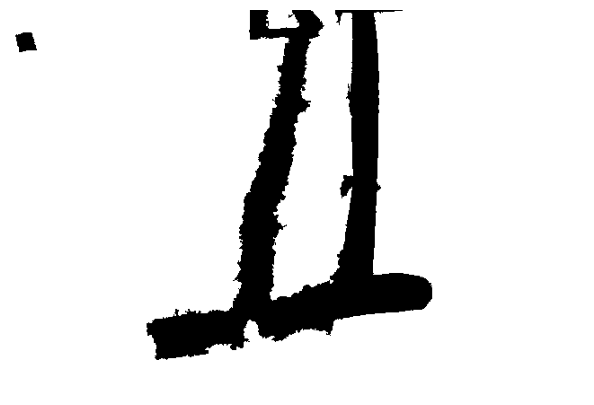

In [93]:
plt.figure(figsize=(10,5))
plt.imshow(alpha_matrix, cmap='gray')
plt.axis('off')
plt.show()

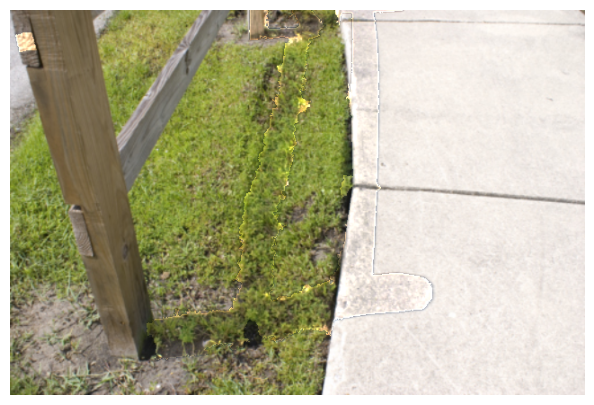

In [94]:
def shadow_remove(image, alpha, epsilon=1e-6):
    r = np.array([1.2, 1.0, 0.7])
    alpha = np.clip(alpha, epsilon, 1)
    rc = []
    for i in range(3):
        factor = (r[i] + 1) / (alpha * r[i] + 1)
        rc.append(image[:, :, i] * factor)
    SF = np.stack(rc, axis=-1)
    SF[SF > 1] = 1
    return SF

SF = shadow_remove(img_rgb_scaled / 255.0, alpha_matrix)

plt.figure(figsize=(10,5))
plt.imshow(SF)
plt.axis('off')
plt.show()